# Assignment 3: Predicting Breast Cancer Relapse

Points: 7.5 pts.

Deliverable: HTML or PDF file to be submitted through Canvas.

**NOTE: You can use GenAI tools to write code for this assignment. As always, please use GenAI only if you have a pretty clear assessment regarding the quality of its responses.** 

**Izzie Mirghani**

## Instructions

The primary goal of this task is to develop, assess, and explore models pertinent to survival analysis.

This dataset encompasses 1,091 distinct cases of breast cancer patients. These individuals were diagnosed at ages ranging from 21.9 to 96.3 years, with an average age of diagnosis at 60.4 years. Patients underwent one of two surgical interventions: Mastectomy (the complete removal of breast tissue) or Breast-conserving surgery (the excision of only the cancerous section of the breast). Included within the dataset is a compilation of demographic and clinical data concerning the patients. Additionally, the dataset tracks instances of cancer recurrence for up to 25 years post-treatment.

Please carefully read the code and run the cells until you reach cells labeled as "Assignment Question". Provide your code and answers in the cell(s) below each question. After answering the questions and saving this notebook, please click on "File", select "Download as" and select "HTML (.html)" or "PDF" to download the notebook. Then, rename the notebook to "assignment4_firstName_lastName" and submit the notebook through Canvas.

Good Luck!

### 1. Notebook Styling and Library Installation

Run the next cell to import all the Python packages needed throughout the notebook. 

In [1]:
# !pip install shap
# !pip install delayed
!conda install -c sebp scikit-survival --yes
!pip install lifelines

Channels:
 - sebp
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [2]:
pip install numpy==2.2.0

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np # Library for math operations
import pandas as pd # Library for data handling
import sklearn # The machine learning library we will be using in this entire course
from sklearn import tree # Tree function is used for visualizing decision tree
from sklearn.metrics import * # Importing function that can be used to calculate different metrics
from sklearn.tree import DecisionTreeClassifier # Importing Decision Tree Algorithm 
from sklearn.model_selection import train_test_split # Importing function that can split a dataset into training and testing set
from sklearn.preprocessing import MinMaxScaler # Importing function for scaling the data
from sklearn.ensemble import GradientBoostingClassifier # Importing GB Classifier
from sklearn.model_selection import GridSearchCV # Importing GridSearchCV
import matplotlib.pyplot as plt # Importing the package for plotting
import seaborn as sns # Importing another package for plotting
from category_encoders import * # Importing the package for handling categorical variables
import shap # Import shap package for interpreting the results

plt.style.use('fivethirtyeight')
from sksurv.nonparametric import kaplan_meier_estimator

### 2. Read & Process the Data

Let’s start with looking at the description of the data and the variables in the data:

In [16]:
data = pd.read_csv("BreastCancerData.csv") # Read data into a data frame
data = data.dropna() # Delete null values (Drop missing data)
data['Relapse'] = np.where(data['Relapse Free Status']=="Recurred",1,0)
data = data[data['Relapse Free Status (Months)']<298] # We assume relapse didn't happen if survived 297 months.
data.head(3) # Display the first 3 rows of data

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status,Relapse
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living,0
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,1
5,MB-0010,78.77,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,No,LumB,1.0,Positve,...,Positive,Yes,2.89,Recurred,Female,ER+/HER2- High Prolif,31.0,4.0,Died of Disease,1


The column that we use to capture the length of time (in months) it took for the relapse (if it happened) is called "Relapse Free Status (Months)". The column that captures whether the relapse happened or not is called "Relapse" (relapse happened if "Relpase" value is 1). These are the two column that you should use for capturing time to event and whether the event happened.

**Q1- [1 point] Plot the Kaplan-Meier Survival Curve for all the patients in the data.**

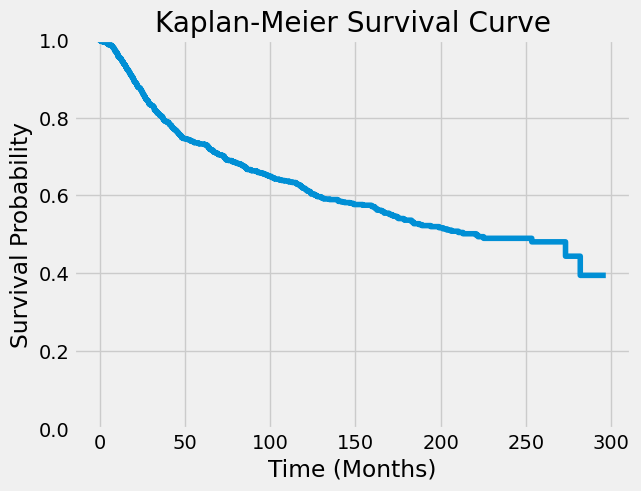

In [17]:
time, survival_prob = kaplan_meier_estimator(
    data['Relapse'].astype(bool),
    data['Relapse Free Status (Months)']
)

fig, ax = plt.subplots()
sns.lineplot(y=survival_prob, x=time, drawstyle='steps-post')
ax.set_ylim(0, 1)
ax.set_xlabel("Time (Months)")
ax.set_ylabel("Survival Probability")
ax.set_title("Kaplan-Meier Survival Curve")
plt.show()

**Q2- [1 point] Fit a Kaplan-Meier model using the data and determine the survival rate 100 months after the surgery?**

In [18]:
adata = pd.DataFrame(zip(time, survival_prob))
adata.columns = ['Time', 'Survival_Rate']

adata[adata['Time'] > 100]

survival_at_100 = adata[adata['Time'] <= 100]['Survival_Rate'].iloc[-1]
print(f"Survival rate at 100 months: {survival_at_100:.4f}")

Survival rate at 100 months: 0.6489


The Survival Rate at 100 months is 64.9%

**Q3. [1.5 points] As noted before, the patients went through two different types of surgery (Mastectomy and Breast Conserving). Create a plot and overlay the survival curve for each type of surgery. Then, report the survival rate 100 months after the surgery for each type of surgery. Which group has a higher survival rate?**

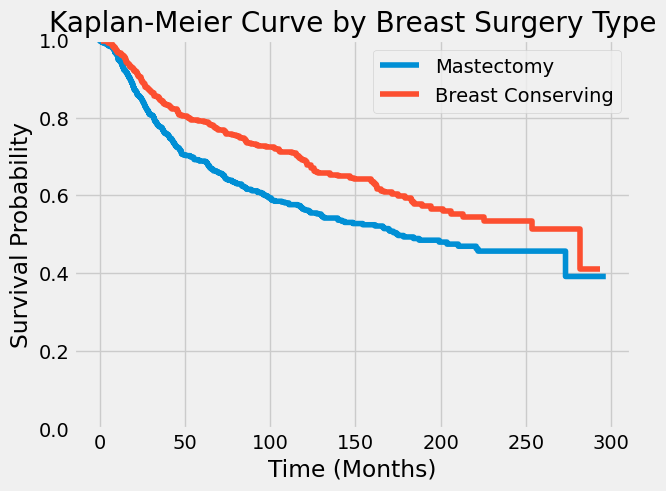

In [19]:
mas = data[data['Type of Breast Surgery']=='Mastectomy']
brc = data[data['Type of Breast Surgery']=='Breast Conserving']

mtime, msurvival_prob = kaplan_meier_estimator(
    mas['Relapse'].astype(bool),
    mas['Relapse Free Status (Months)']
)

btime, bsurvival_prob = kaplan_meier_estimator(
    brc['Relapse'].astype(bool),
    brc['Relapse Free Status (Months)']
)

fig, ax = plt.subplots()
sns.lineplot(x=mtime, y=msurvival_prob, drawstyle='steps-post', label='Mastectomy')
sns.lineplot(x=btime, y=bsurvival_prob, drawstyle='steps-post', label='Breast Conserving')
ax.set_ylim(0, 1)
ax.set_xlabel("Time (Months)")
ax.set_ylabel("Survival Probability")
ax.set_title("Kaplan-Meier Curve by Breast Surgery Type")
ax.legend()
plt.show()

In [20]:
mdata = pd.DataFrame(zip(mtime, msurvival_prob))
mdata.columns = ['Time', 'Survival_Rate']
msurvival_at_100 = mdata[mdata['Time'] <= 100]['Survival_Rate'].iloc[-1]
print(f"Mastectomy survival rate at 100 months: {msurvival_at_100:.4f}")

bdata = pd.DataFrame(zip(btime, bsurvival_prob))
bdata.columns = ['Time', 'Survival_Rate']
bsurvival_at_100 = bdata[bdata['Time'] <= 100]['Survival_Rate'].iloc[-1]
print(f"Breast Conserving survival rate at 100 months: {bsurvival_at_100:.4f}")

Mastectomy survival rate at 100 months: 0.5931
Breast Conserving survival rate at 100 months: 0.7237


## My Answer 

According to the plot, the group that had the breast conserving operation has a much higher survival rate at 100 months.

### Cox Proportional Hazard Model:

Using the following columns, we want to build a Cox Proportional Hazard model.

Columns to be used:

['Age at Diagnosis', 'Type of Breast Surgery','Chemotherapy',
       'Cohort', 'ER Status', 'Hormone Therapy',
       'Inferred Menopausal State',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Radio Therapy','Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage',
             'Relapse Free Status (Months)','Relapse']
       
Since we need to transform the categorical variables using category_encoders before using them in the Cox model, we first look at the data types in the data:

In [21]:
data = data[['Age at Diagnosis', 'Type of Breast Surgery','Chemotherapy',
       'Cohort', 'ER Status', 'Hormone Therapy',
       'Inferred Menopausal State',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Radio Therapy','Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage',
             'Relapse Free Status (Months)','Relapse']]

data.info()

<class 'pandas.DataFrame'>
Index: 1091 entries, 1 to 1743
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age at Diagnosis               1091 non-null   float64
 1   Type of Breast Surgery         1091 non-null   str    
 2   Chemotherapy                   1091 non-null   str    
 3   Cohort                         1091 non-null   float64
 4   ER Status                      1091 non-null   str    
 5   Hormone Therapy                1091 non-null   str    
 6   Inferred Menopausal State      1091 non-null   str    
 7   Primary Tumor Laterality       1091 non-null   str    
 8   Lymph nodes examined positive  1091 non-null   float64
 9   Mutation Count                 1091 non-null   float64
 10  Nottingham prognostic index    1091 non-null   float64
 11  Oncotree Code                  1091 non-null   str    
 12  Radio Therapy                  1091 non-null   str    
 13  Sex 

We then select all of the object columns from the list above to be transformed:

In [22]:
from category_encoders import *
encoder = PolynomialEncoder(cols=['Type of Breast Surgery', 'Chemotherapy', 
                              'ER Status', 'Hormone Therapy', 
                              'Inferred Menopausal State', 
                              'Primary Tumor Laterality', 
                              'Oncotree Code', 'Radio Therapy', 'Sex', 
                              '3-Gene classifier subtype']).fit(data)

data = encoder.transform(data)

In [23]:
data.head(2)

,Age at Diagnosis,Type of Breast Surgery_0,Chemotherapy_0,Cohort,ER Status_0,Hormone Therapy_0,Inferred Menopausal State_0,Primary Tumor Laterality_0,Lymph nodes examined positive,Mutation Count,...,Oncotree Code_2,Oncotree Code_3,Radio Therapy_0,3-Gene classifier subtype_0,3-Gene classifier subtype_1,3-Gene classifier subtype_2,Tumor Size,Tumor Stage,Relapse Free Status (Months),Relapse
1,43.19,-0.707107,-0.707107,1.0,-0.707107,-0.707107,-0.707107,-0.707107,0.0,2.0,...,-0.316228,0.119523,-0.707107,-0.67082,0.5,-0.223607,10.0,1.0,83.52,0
4,76.97,0.707107,0.707107,1.0,-0.707107,-0.707107,0.707107,-0.707107,8.0,2.0,...,0.632456,-0.478091,-0.707107,-0.67082,0.5,-0.223607,40.0,2.0,18.55,1


Since the Polynomial encoding create a new column called "intercept", we remove it from the data (if populated above):

In [12]:
#data = data.drop(columns=['intercept'])

Now, we can build a model using the columns in the transformed data:

In [24]:
from lifelines import CoxPHFitter

In [25]:
# Using Cox Proportional Hazards model
cph = CoxPHFitter()   ## Instantiate the class to create a cph object
cph.fit(data, 'Relapse Free Status (Months)', 
        event_col='Relapse')   ## Fit the data to train the model
cph.print_summary()    ## Have a look at the significance of the features

<lifelines.CoxPHFitter: fitted with 1091 total observations, 637 right-censored observations>
             duration col = 'Relapse Free Status (Months)'
                event col = 'Relapse'
      baseline estimation = breslow
   number of observations = 1091
number of events observed = 454
   partial log-likelihood = -2893.42
         time fit was run = 2026-02-27 01:54:15 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis               0.00      1.00      0.01           -0.01            0.01                0.99                1.01
Type of Breast Surgery_0      -0.04      0.96      0.09           -0.22            0.13                0.81                1.14
Chemotherapy_0                -0.00      1.00      0.11           -0.22            0.21                0.80                1.24
Cohort                         0.03      1.03      0.06           -0.08            0.14                0.92                1.15
ER Status_0                   -0.17      0.84      0.14           -0.45            0.10                0.64                1.11
Hormone Therapy_0              0.27      1.31      0.09            0.10            0.44                1.10                1.55
Inferred Menopausal State_0   -0.09      0.91      0.12           -0.33            0.14                0.72                1.15
Primary Tumor Laterality_0     0.03      1.03      0.07           -0.10            0.16                0.90                1.18
Lymph nodes examined positive  0.06      1.06      0.01            0.03            0.08                1.03                1.08
Mutation Count                 0.01      1.01      0.01           -0.02            0.03                0.98                1.03
Nottingham prognostic index    0.18      1.19      0.07            0.03            0.32                1.04                1.38
Oncotree Code_0               -0.81      0.45      0.68           -2.13            0.52                0.12                1.68
Oncotree Code_1               -0.34      0.71      0.58           -1.47            0.80                0.23                2.22
Oncotree Code_2                0.23      1.26      0.56           -0.86            1.32                0.42                3.76
Oncotree Code_3                0.38      1.46      0.39           -0.38            1.14                0.68                3.12
Radio Therapy_0                0.16      1.17      0.09           -0.02            0.33                0.98                1.40
3-Gene classifier subtype_0    0.22      1.24      0.15           -0.08            0.51                0.93                1.67
3-Gene classifier subtype_1    0.35      1.41      0.11            0.13            0.56                1.14                1.75
3-Gene classifier subtype_2   -0.05      0.95      0.14           -0.32            0.23                0.73                1.25
Tumor Size                     0.01      1.01      0.00            0.00            0.01                1.00                1.01
Tumor Stage                    0.26      1.30      0.10            0.06            0.47                1.06                1.60

                               cmp to     z      p  -log2(p)
covariate                                                   
Age at Diagnosis                 0.00  0.29   0.77      0.37
Type of Breast Surgery_0         0.00 -0.48   0.63      0.66
Chemotherapy_0                   0.00 -0.03   0.98      0.03
Cohort                           0.00  0.52   0.60      0.73
ER Status_0                      0.00 -1.23   0.22      2.19
Hormone Therapy_0                0.00  3.09 <0.005      8.96
Inferred Menopausal State_0      0.00 -0.78   0.43      1.20
Primary Tumor Laterality_0       0.00  0.45   0.65      0.62
Lymph nodes examined positive    0.00  4.48 <0.005     17.0

**Q4- [4 points] Now answer the following questions based on the Cox output above.**

Q4.1. Which variables in the list above have a significant association with the hazard rate? 

1.) The "3-Gene classifier subtype_1" variable has a significant association with the hazard rate, as it has a high coefficient of 0.35 and a statistically significant P-value (<0.005). 

2.) Next, the "Hormone Therapy_0" variable has a significant association with the hazard rate, as it has the next highest coefficient of 0.27 and a statistically significant P-value (<0.005).

3.) Additionally, the "Tumor Stage" variable also had a significant association with the hazard rate due to its high coefficient of 0.26 and a statistically significant P-value of 0.01.

4.) Next, the "Nottingham prognostic index" variable had a significant association with the hazard rate due its moderately high coefficient of 0.18 and a statistically significant P-value of 0.01.

5.) Additionally, the "Lymph nodes examined positive" variable had a significant association with the hazard rate due its statistically significant P-value of <0.005, even though it has a smaller coefficient of 0.06.

6.) Lastly, the "Tumor Size" variable had a significant association with the hazard rate due its relatively small coefficient of 0.01 but its effect size is statistically significant due its P-value of 0.01.

Q4.2. Which variables in Q4.1 have a negative association with the hazard rate?

All the variables identified in 4.1 have a positive association with the hazard rate due to their coefficients.



Although, the "Oncotree Code_1" variable has a highly negative association with the hazard rate with a coefficient of -0.81 but it is not at the statistically significant level, so it's large negative coefficient cannot be validated and trusted to be appear in another dataset.

Q4.3. Rerun the Cox analysis but only use the significant predictors you identified in Q4.1

In [26]:
data_filtered = data[["3-Gene classifier subtype_1", 
                      "Hormone Therapy_0", 
                      "Tumor Stage", 
                      "Nottingham prognostic index",
                      "Tumor Size",
                      "Lymph nodes examined positive",
                      "Relapse Free Status (Months)", 
                      "Relapse"]]

cph2 = CoxPHFitter()
cph2.fit(data_filtered, 'Relapse Free Status (Months)', 
        event_col='Relapse')
cph2.print_summary() 

<lifelines.CoxPHFitter: fitted with 1091 total observations, 637 right-censored observations>
             duration col = 'Relapse Free Status (Months)'
                event col = 'Relapse'
      baseline estimation = breslow
   number of observations = 1091
number of events observed = 454
   partial log-likelihood = -2899.48
         time fit was run = 2026-02-27 01:54:46 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
3-Gene classifier subtype_1    0.35      1.42      0.10            0.16            0.54                1.17                1.72
Hormone Therapy_0              0.28      1.32      0.07            0.14            0.42                1.15                1.53
Tumor Stage                    0.27      1.31      0.10            0.07            0.47                1.07                1.59
Nottingham prognostic index    0.15      1.16      0.06            0.03            0.27                1.03                1.32
Tumor Size                     0.01      1.01      0.00            0.00            0.01                1.00                1.01
Lymph nodes examined positive  0.05      1.06      0.01            0.03            0.08                1.03                1.08

                               cmp to    z      p  -log2(p)
covariate                                                  
3-Gene classifier subtype_1      0.00 3.61 <0.005     11.66
Hormone Therapy_0                0.00 3.90 <0.005     13.33
Tumor Stage                      0.00 2.66   0.01      7.01
Nottingham prognostic index      0.00 2.39   0.02      5.89
Tumor Size                       0.00 2.50   0.01      6.32
Lymph nodes examined positive    0.00 4.37 <0.005     16.30
---
Concordance = 0.67
Partial AIC = 5810.95
log-likelihood ratio test = 140.12 on 6 df
-log2(p) of ll-ratio test = 89.77

Q4.4. Explain what Concordance is without using technical terminology.

Concordance is the ability of a model to rank subjects or samples by risk that they will experience the event. Subjects or samples that have a higher predicted risk are predicted to experience the event earlier. This measure is on a 0.50 to 1.0 scale.

Q4.5. Compare the values for Concordance for the first Cox model (with all the predictors) with that of the model you built in Q4.3. Are they similar? Based on the values for Concordance, between the two Cox models, which one do you prefer to use in practice? Explain your answer by mentioning at least one technical reason and one business reason. 

The concordance of the first model was pretty high at 0.68, but this was using a number of non-statistically significant variables. After subsetting the data and only including variables that have significant associations with the hazard rate, the new model's concordance was 0.67. This is very comparable to the first model with only a loss of around 0.01 in concordance, but with a reduction of 13 redundant variables to reduce to the dimensionality of the dataset. Additionally, all of the variables P-values in the second model were at the highly statistically significant level.

Further, a few of the coefficients of the statistically significant variables used in the second model increased compared to the first model, meaning that a multicollinear effect may have been present in the first model. Although, it is notable that there is still potentially a multicollinear effect between Tumor Size and Tumor Stage, since their P-values decrease from <0.005 to 0.01 when both variables are included in the second model. This small difference in P-values does not raise concern. In the second model, these variables are able to contribute better predictive power at higher statistically significant levels. Finally, the second model allows us to focus on the true predictors and contributors of breast cancer relapse.

I would prefer to use the second model in practice because I can rely on the statistically significant variables to generalize well to data from new subjects, resulting in accurate predictions of when a patient will relapse. If I am able to accurately prepare for a patient to experience a relapse, this will reduce hospital costs associated with collecting data on redundant features, allow them to prepare for the potential relapse, ensure there is treatment available, and give doctors the best chance to save the patient's life.